Solution status: optimal (linprog)
Optimal x: [1.33333333 1.33333333]
Optimal objective value z: 9.333333333333334


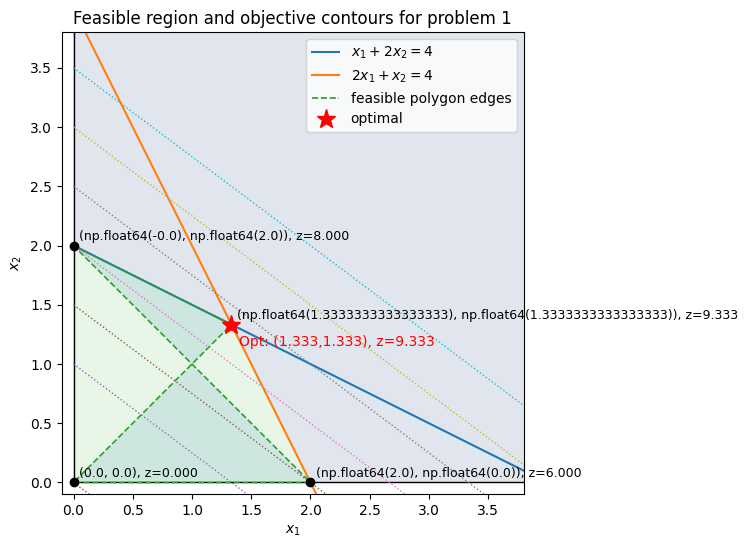

In [ ]:
# We'll solve the first LP and plot the feasible region + objective contours.
# Problem 1:
# Maximize z = 3 x1 + 4 x2
# s.t. x1 + 2 x2 <= 4
#      2 x1 + x2 <= 4
#      x1, x2 >= 0
#
# We'll attempt to use scipy.linprog; if not available, we'll compute vertices manually.
# Then we produce a matplotlib plot of feasible region and objective contours and mark optimum.

import math
import numpy as np
import matplotlib.pyplot as plt

# define constraints
A = np.array([[1,2],
              [2,1]])
b = np.array([4,4])

c = np.array([3,4])  # maximize c^T x

# try scipy linprog
use_scipy = True
sol = None
try:
    from scipy.optimize import linprog
    # linprog does minimization -> minimize -c^T x
    res = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None),(0, None)], method="highs")
    if res.success:
        sol = {"x": res.x, "fun": -res.fun, "status": "optimal (linprog)"}
    else:
        sol = {"status": f"linprog failed: {res.message}"}
except Exception as e:
    use_scipy = False
    sol = {"status": f"scipy not available or linprog failed: {e}"}

# fallback: compute all intersection vertices of halfspaces including axes and evaluate objective
def compute_vertices(A, b):
    # halfspaces: A x <= b, x>=0
    lines = []
    # each inequality as line: a1 x + a2 y = b
    for i in range(A.shape[0]):
        a1,a2 = A[i]
        lines.append((a1,a2,b[i]))
    # include x=0 and y=0 as lines
    lines.append((1,0,0))
    lines.append((0,1,0))
    verts = []
    for i in range(len(lines)):
        for j in range(i+1, len(lines)):
            a1,a2,r1 = lines[i]
            b1,b2,r2 = lines[j]
            det = a1*b2 - a2*b1
            if abs(det) < 1e-9:
                continue
            x = (r1*b2 - a2*r2)/det
            y = (a1*r2 - r1*b1)/det
            # check feasibility: A x <= b + tol and x,y >= -tol
            tol = 1e-8
            vec = np.array([x,y])
            if np.all(A.dot(vec) <= b + 1e-7) and x >= -1e-7 and y >= -1e-7:
                verts.append((x,y))
    # unique
    uniq = []
    for v in verts:
        if not any(np.allclose(v,u,rtol=1e-6,atol=1e-6) for u in uniq):
            uniq.append(v)
    return uniq

vertices = compute_vertices(A,b)
# evaluate objective
vals = [ (v, c.dot(np.array(v))) for v in vertices ]
vals_sorted = sorted(vals, key=lambda t: -t[1])  # descending because maximize

# choose best from fallback
if sol is None or ("x" not in sol):
    if len(vals_sorted)>0:
        best = vals_sorted[0]
        sol = {"x": np.array(best[0]), "fun": best[1], "status": "optimal (vertex enumeration)"}
    else:
        sol = {"status":"No feasible vertex found"}

# Print solution
print("Solution status:", sol.get("status"))
if "x" in sol:
    print("Optimal x:", sol["x"])
    print("Optimal objective value z:", sol["fun"])

# Prepare plot
fig, ax = plt.subplots(figsize=(6,6))

# plot feasible region by sampling grid and showing feasible points
x1 = np.linspace(0, max(4, sol.get("x",[0,0])[0]*1.5+1), 400)
x2 = np.linspace(0, max(4, sol.get("x",[0,0])[1]*1.5+1), 400)
X1, X2 = np.meshgrid(x1,x2)
feas = (X1 + 2*X2 <= 4 + 1e-9) & (2*X1 + X2 <= 4 + 1e-9) & (X1>=-1e-9) & (X2>=-1e-9)
ax.contourf(X1, X2, feas, levels=[-0.5,0.5,1.5], alpha=0.15)

# plot constraint lines
# x1 + 2 x2 = 4  => x2 = (4 - x1)/2
x1_line = np.linspace(0,4,200)
x2_line1 = (4 - x1_line)/2
x2_line2 = (4 - 2*x1_line)
ax.plot(x1_line, x2_line1, label=r'$x_1+2x_2=4$')
# 2 x1 + x2 = 4 => x2 = 4 - 2 x1
ax.plot(x1_line, x2_line2, label=r'$2x_1+x_2=4$')

# axes
ax.plot([0,0],[0, max(x2)*1.05], 'k', linewidth=1)
ax.plot([0, max(x1)*1.05],[0,0], 'k', linewidth=1)

# feasible polygon edges using vertices sorted ccw
poly = np.array(sorted(vertices, key=lambda p: math.atan2(p[1], p[0])))
if poly.size>0:
    # close polygon for plotting
    poly_closed = np.vstack([poly, poly[0]])
    ax.plot(poly_closed[:,0], poly_closed[:,1], linestyle='--', linewidth=1.2, label='feasible polygon edges')
    ax.fill(poly_closed[:,0], poly_closed[:,1], alpha=0.12)

# plot objective contours
# z = 3 x1 + 4 x2 = t  => x2 = (t - 3 x1)/4
t_vals = [0,4,6,8,10,12,14]
for t in t_vals:
    x2_obj = (t - 3*x1_line)/4
    ax.plot(x1_line, x2_obj, linestyle=':', linewidth=1)

# mark vertices and annotate objective at vertices
for v,val in vals:
    ax.plot(v[0], v[1], 'ko')
    ax.text(v[0]+0.05, v[1]+0.05, f"{v}, z={val:.3f}", fontsize=9)

# mark optimal
if "x" in sol:
    opt = sol["x"]
    ax.plot(opt[0], opt[1], 'r*', markersize=14, label='optimal')
    ax.text(opt[0]+0.06, opt[1]-0.18, f"Opt: ({opt[0]:.3f},{opt[1]:.3f}), z={sol['fun']:.3f}", color='red')

ax.set_xlim(-0.1, max(x1)*0.95)
ax.set_ylim(-0.1, max(x2)*0.95)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title('Feasible region and objective contours for problem 1')
ax.legend(loc='upper right')
ax.set_aspect('equal', adjustable='box')
plt.show()


In [ ]:
import numpy as np

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
C_dot = A @ B
print("\nMatrix Addition:\n", C_dot)


Matrix Addition:
 [[19 22]
 [43 50]]


In [ ]:
// second question
/*Consider the following LP: Minimize 𝑧 = 𝑥1 + 𝑥2
Subject to: 𝑥1 ≥ 2; 𝑥2 ≥ 3; 𝑥1 + 𝑥2 ≤ 4; 𝑥1, 𝑥2 ≥ 0
Use linprog to attempt solving it. Explain why the status indicates infeasibility, and suggest how to
modify one constraint to make it feasible*/

